# Day 4 Advanced: Transfer Learning with EfficientNetB0

**Goal:** Achieve 88-92% accuracy using transfer learning

**What we'll do:**
1. Load EfficientNetB0 pretrained on ImageNet
2. Convert grayscale images to RGB
3. Fine-tune the model on brain tumor data
4. Compare with baseline CNN (76.83%)

**Expected improvement:** 76% → 88-92% (+12-16%)

**Why EfficientNetB0?**
- State-of-the-art efficiency
- Only 5M parameters (lightweight)
- Excellent performance/speed trade-off
- Works well for medical imaging

---

**Training Strategy:**
1. **Phase 1:** Freeze base model, train classifier (5 epochs)
2. **Phase 2:** Unfreeze top layers, fine-tune (10 epochs)
3. **Phase 3:** Lower learning rate, final training (5 epochs)

**Expected time:** 45-60 minutes (with GPU)

---

## 1. Import Libraries

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from datetime import datetime

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.optimizers import Adam

# Add src to path for imports
sys.path.append('../../src')
from training.transfer_learning_utils import GrayscaleToRGBGenerator, create_rgb_generators

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU available: {len(gpus)} GPU(s)")
else:
    print("⚠️  No GPU - training will be slow!")

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

2025-10-24 21:31:57.199699: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0
Keras version: 3.11.3
✅ GPU available: 1 GPU(s)


## 2. Configuration

In [2]:
# Paths
TRAIN_CSV = "../../outputs/data_splits/train_split.csv"
VAL_CSV = "../../outputs/data_splits/val_split.csv"
TEST_CSV = "../../outputs/data_splits/test_split.csv"

# Output directories
MODEL_DIR = "../../outputs/models/transfer_learning"
HISTORY_DIR = "../../outputs/training_history/transfer_learning"
VIZ_DIR = "../../outputs/visualizations"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(HISTORY_DIR, exist_ok=True)
os.makedirs(VIZ_DIR, exist_ok=True)

# Hyperparameters
IMG_SIZE = (224, 224)  # EfficientNet default size (ImageNet)
BATCH_SIZE = 32
LEARNING_RATE_PHASE1 = 0.001  # Training classifier only
LEARNING_RATE_PHASE2 = 0.0001  # Fine-tuning
LEARNING_RATE_PHASE3 = 0.00001  # Final training

# Class names
CLASS_NAMES = ['glioma', 'meningioma', 'pituitary']
NUM_CLASSES = len(CLASS_NAMES)

print("Configuration:")
print(f"  Model: EfficientNetB0")
print(f"  Image size: {IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Classes: {CLASS_NAMES}")

Configuration:
  Model: EfficientNetB0
  Image size: (224, 224)
  Batch size: 32
  Classes: ['glioma', 'meningioma', 'pituitary']


## 3. Load Data

In [3]:
# Load CSV files
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

# Ensure label is string
train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)

print("Data loaded:")
print(f"  Train: {len(train_df)} images")
print(f"  Val:   {len(val_df)} images")
print(f"  Test:  {len(test_df)} images")

Data loaded:
  Train: 4863 images
  Val:   855 images
  Test:  1463 images


## 4. Create RGB Data Generators

**Important:** EfficientNet requires RGB input (3 channels), but our images are grayscale.

We'll convert by replicating the grayscale channel 3 times.

In [4]:
# Create RGB generators (normalized [0, 1])
train_generator, val_generator, test_generator = create_rgb_generators(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\n✅ RGB data generators created!")
print(f"Steps per epoch: {len(train_generator)}")
print(f"Validation steps: {len(val_generator)}")

# Test generator output
test_batch_x, test_batch_y = next(iter(train_generator))
print(f"\nBatch shape: {test_batch_x.shape} (should be [batch, 128, 128, 3])")
print(f"Labels shape: {test_batch_y.shape}")
print(f"Pixel range: [{test_batch_x.min():.2f}, {test_batch_x.max():.2f}] (normalized [0, 1])")

Found 4863 validated image filenames belonging to 3 classes.
Found 855 validated image filenames belonging to 3 classes.
Found 855 validated image filenames belonging to 3 classes.
Found 1463 validated image filenames belonging to 3 classes.
Found 1463 validated image filenames belonging to 3 classes.

✅ RGB data generators created!
Steps per epoch: 152
Validation steps: 27

✅ RGB data generators created!
Steps per epoch: 152
Validation steps: 27

Batch shape: (32, 224, 224, 3) (should be [batch, 128, 128, 3])
Labels shape: (32, 3)
Pixel range: [0.00, 255.00] (normalized [0, 1])

Batch shape: (32, 224, 224, 3) (should be [batch, 128, 128, 3])
Labels shape: (32, 3)
Pixel range: [0.00, 255.00] (normalized [0, 1])


## 5. Build Transfer Learning Model

**Architecture:**
- Base: EfficientNetB0 (pretrained on ImageNet)
- GlobalAveragePooling2D
- Dense(256) + BatchNorm + Dropout
- Dense(128) + BatchNorm + Dropout
- Dense(3, softmax)

In [5]:
def build_efficientnet_model(num_classes=3, trainable=False):
    """
    Build EfficientNetB0 model with custom classifier.
    
    Args:
        num_classes: Number of output classes
        trainable: Whether base model is trainable
    
    Returns:
        Compiled Keras model
    """
    # First, build EfficientNetB0 WITHOUT pretrained weights
    # This avoids the shape mismatch issue during weight loading
    base_model = EfficientNetB0(
        include_top=False,
        weights=None,  # No weights initially
        input_shape=(224, 224, 3),  # RGB input
        pooling='avg'
    )
    
    # Now manually load ImageNet weights
    # This will work because the model architecture is correct (RGB)
    print("Loading ImageNet weights manually...")
    weights_path = tf.keras.utils.get_file(
        'efficientnetb0_notop.h5',
        'https://storage.googleapis.com/keras-applications/efficientnetb0_notop.h5',
        cache_subdir='models'
        # No file_hash - let it download without verification
    )
    base_model.load_weights(weights_path)
    print("✅ ImageNet weights loaded successfully!")
    
    # Freeze/unfreeze base model
    base_model.trainable = trainable
    
    # Build model on top
    inputs = base_model.input
    x = base_model.output
    
    # Custom classifier
    x = Dense(256, activation='relu', name='fc1')(x)
    x = BatchNormalization(name='bn1')(x)
    x = Dropout(0.5, name='dropout1')(x)
    
    x = Dense(128, activation='relu', name='fc2')(x)
    x = BatchNormalization(name='bn2')(x)
    x = Dropout(0.5, name='dropout2')(x)
    
    outputs = Dense(num_classes, activation='softmax', name='predictions')(x)
    
    model = Model(inputs=inputs, outputs=outputs, name='EfficientNetB0_BrainTumor')
    
    return model, base_model

# Build model (base frozen initially)
print("Building EfficientNetB0 model...")
print("Note: Downloading ImageNet weights if not cached (this may take a minute)...\n")

model, base_model = build_efficientnet_model(num_classes=NUM_CLASSES, trainable=False)

print("\n✅ Model built successfully!")
print("\nModel architecture:")
model.summary()

# Count parameters
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
non_trainable_params = sum([tf.size(w).numpy() for w in model.non_trainable_weights])
total_params = trainable_params + non_trainable_params

print(f"\nParameter counts:")
print(f"  Trainable: {trainable_params:,}")
print(f"  Non-trainable: {non_trainable_params:,}")
print(f"  Total: {total_params:,}")

Building EfficientNetB0 model...
Note: Downloading ImageNet weights if not cached (this may take a minute)...



I0000 00:00:1761321720.328935   45513 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2614 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Loading ImageNet weights manually...
✅ ImageNet weights loaded successfully!

✅ Model built successfully!

Model architecture:
✅ ImageNet weights loaded successfully!

✅ Model built successfully!

Model architecture:


Model: "EfficientNetB0_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ normalization[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_

 Total params: 4,412,326 (16.83 MB)

 Trainable params: 361,987 (1.38 MB)

 Non-trainable params: 4,050,339 (15.45 MB)


Parameter counts:
  Trainable: 361,987
  Non-trainable: 4,050,339
  Total: 4,412,326


## 6. Phase 1: Train Classifier Only (5 epochs)

First, we train only the custom classifier layers while keeping EfficientNet frozen.

This allows the classifier to adapt to our brain tumor data.

In [6]:
print("="*70)
print("PHASE 1: Training Classifier Only")
print("="*70)
print("Base model: FROZEN")
print("Learning rate: 0.001")
print("Epochs: 5\n")

# Compile model
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE_PHASE1),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
callbacks_phase1 = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# Train
history_phase1 = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    callbacks=callbacks_phase1,
    verbose=1
)

print("\n✅ Phase 1 completed!")
print(f"Final accuracy: {history_phase1.history['accuracy'][-1]:.4f}")
print(f"Final val_accuracy: {history_phase1.history['val_accuracy'][-1]:.4f}")

PHASE 1: Training Classifier Only
Base model: FROZEN
Learning rate: 0.001
Epochs: 5



/projects/ai-ml/BrainTumorProject/.venv/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


2025-10-24 21:32:09.712028: I external/local_xla/xla/service/service.cc:163] XLA service 0x7c759804dc50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-24 21:32:09.712046: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2025-10-24 21:32:10.041791: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-24 21:32:10.041791: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-24 21:32:11.393108: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2025-10-24 21:32:11.393108: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400
2025-10-24 21:32:17.257147: E external/local_xla

 76/152 ━━━━━━━━━━━━━━━━━━━━ 8s 109ms/step - accuracy: 0.5601 - loss: 1.2204

2025-10-24 21:32:39.464445: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-24 21:32:39.610242: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-24 21:32:40.082647: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-24 21:32:40.228051: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-24 21:32:40.082647: E external/local_xla/xla/stream_

152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.6127 - loss: 1.0672

2025-10-24 21:33:05.911087: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-24 21:33:06.052156: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-24 21:33:06.507211: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-24 21:33:06.651947: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-24 21:33:06.507211: E external/local_xla/xla/stream_

152/152 ━━━━━━━━━━━━━━━━━━━━ 68s 306ms/step - accuracy: 0.6850 - loss: 0.8524 - val_accuracy: 0.7462 - val_loss: 0.5556 - learning_rate: 0.0010
Epoch 2/5
Epoch 2/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 20s 131ms/step - accuracy: 0.7611 - loss: 0.6197 - val_accuracy: 0.8269 - val_loss: 0.4148 - learning_rate: 0.0010
Epoch 3/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 20s 131ms/step - accuracy: 0.7611 - loss: 0.6197 - val_accuracy: 0.8269 - val_loss: 0.4148 - learning_rate: 0.0010
Epoch 3/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 19s 126ms/step - accuracy: 0.7956 - loss: 0.5010 - val_accuracy: 0.8281 - val_loss: 0.4285 - learning_rate: 0.0010
Epoch 4/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 19s 126ms/step - accuracy: 0.7956 - loss: 0.5010 - val_accuracy: 0.8281 - val_loss: 0.4285 - learning_rate: 0.0010
Epoch 4/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 19s 126ms/step - accuracy: 0.8137 - loss: 0.4674 - val_accuracy: 0.8257 - val_loss: 0.3878 - learning_rate: 0.0010
Epoch 5/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 19s 126ms/step - accuracy: 0.8137 - l

## 7. Phase 2: Fine-tune Top Layers (10 epochs)

Now we unfreeze the top layers of EfficientNet and fine-tune with a lower learning rate.

In [7]:
print("\n" + "="*70)
print("PHASE 2: Fine-tuning Top Layers")
print("="*70)

# Unfreeze top 50 layers
base_model.trainable = True

# Freeze bottom layers
for layer in base_model.layers[:-50]:
    layer.trainable = False

# Count trainable layers
trainable_layers = sum([layer.trainable for layer in base_model.layers])
print(f"Trainable layers in base model: {trainable_layers} / {len(base_model.layers)}")

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE_PHASE2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Learning rate: {LEARNING_RATE_PHASE2}")
print(f"Epochs: 10\n")

# Callbacks
model_path_phase2 = os.path.join(MODEL_DIR, f"efficientnet_phase2_{timestamp}.keras")
callbacks_phase2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=model_path_phase2,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-8,
        verbose=1
    )
]

# Train
history_phase2 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks_phase2,
    verbose=1
)

print("\n✅ Phase 2 completed!")
print(f"Best val_accuracy: {max(history_phase2.history['val_accuracy']):.4f}")


PHASE 2: Fine-tuning Top Layers
Trainable layers in base model: 50 / 238
Learning rate: 0.0001
Epochs: 10

Epoch 1/10
Epoch 1/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.7688 - loss: 0.5550
Epoch 1: val_loss improved from None to 0.34230, saving model to ../../outputs/models/transfer_learning/efficientnet_phase2_20251024_213202.keras

Epoch 1: val_loss improved from None to 0.34230, saving model to ../../outputs/models/transfer_learning/efficientnet_phase2_20251024_213202.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 63s 262ms/step - accuracy: 0.7882 - loss: 0.5083 - val_accuracy: 0.8480 - val_loss: 0.3423 - learning_rate: 1.0000e-04
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 63s 262ms/step - accuracy: 0.7882 - loss: 0.5083 - val_accuracy: 0.8480 - val_loss: 0.3423 - learning_rate: 1.0000e-04
Epoch 2/10
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8418 - loss: 0.3972
Epoch 2: val_loss improved from 0.34230 to 0.31710, saving model to ../../outputs/models/transfer_learnin

## 8. Phase 3: Final Training (5 epochs)

Final training with very low learning rate for maximum accuracy.

In [8]:
print("\n" + "="*70)
print("PHASE 3: Final Training")
print("="*70)

# Unfreeze all layers
base_model.trainable = True
for layer in base_model.layers:
    layer.trainable = True

print(f"All layers unfrozen")
print(f"Learning rate: {LEARNING_RATE_PHASE3}")
print(f"Epochs: 5\n")

# Recompile with very low learning rate
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE_PHASE3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
model_path_final = os.path.join(MODEL_DIR, f"efficientnet_final_{timestamp}.keras")
history_csv = os.path.join(HISTORY_DIR, f"efficientnet_history_{timestamp}.csv")

callbacks_phase3 = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=model_path_final,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    CSVLogger(filename=history_csv)
]

# Train
history_phase3 = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    callbacks=callbacks_phase3,
    verbose=1
)

print("\n✅ Phase 3 completed!")
print(f"Final model saved to: {model_path_final}")


PHASE 3: Final Training
All layers unfrozen
Learning rate: 1e-05
Epochs: 5

Epoch 1/5
Epoch 1/5


2025-10-24 21:39:05.686674: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-24 21:39:05.846753: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 70/152 ━━━━━━━━━━━━━━━━━━━━ 14s 173ms/step - accuracy: 0.7798 - loss: 0.5815

2025-10-24 21:39:50.234733: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-24 21:39:50.394201: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-24 21:39:57.412135: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-24 21:39:57.558781: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-10-24 21:39:57.412135: E external/local_xla/xla/stream_

152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.7953 - loss: 0.5381
Epoch 1: val_loss improved from None to 0.50189, saving model to ../../outputs/models/transfer_learning/efficientnet_final_20251024_213202.keras

Epoch 1: val_loss improved from None to 0.50189, saving model to ../../outputs/models/transfer_learning/efficientnet_final_20251024_213202.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 128s 460ms/step - accuracy: 0.8186 - loss: 0.4752 - val_accuracy: 0.8070 - val_loss: 0.5019
Epoch 2/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 128s 460ms/step - accuracy: 0.8186 - loss: 0.4752 - val_accuracy: 0.8070 - val_loss: 0.5019
Epoch 2/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.8577 - loss: 0.3586
Epoch 2: val_loss did not improve from 0.50189
152/152 ━━━━━━━━━━━━━━━━━━━━ 28s 185ms/step - accuracy: 0.8637 - loss: 0.3516 - val_accuracy: 0.6667 - val_loss: 0.8450
Epoch 3/5

Epoch 2: val_loss did not improve from 0.50189
152/152 ━━━━━━━━━━━━━━━━━━━━ 28s 185ms/step - accuracy: 0.8637 - los

## 9. Combine Training History

In [9]:
# Combine histories from all phases
combined_history = {
    'accuracy': (history_phase1.history['accuracy'] + 
                 history_phase2.history['accuracy'] + 
                 history_phase3.history['accuracy']),
    'val_accuracy': (history_phase1.history['val_accuracy'] + 
                     history_phase2.history['val_accuracy'] + 
                     history_phase3.history['val_accuracy']),
    'loss': (history_phase1.history['loss'] + 
             history_phase2.history['loss'] + 
             history_phase3.history['loss']),
    'val_loss': (history_phase1.history['val_loss'] + 
                 history_phase2.history['val_loss'] + 
                 history_phase3.history['val_loss'])
}

print(f"Total epochs: {len(combined_history['accuracy'])}")
print(f"Best val_accuracy: {max(combined_history['val_accuracy']):.4f}")

Total epochs: 19
Best val_accuracy: 0.9123


## 10. Visualize Training History

Training curves saved to: ../../outputs/visualizations/day4_advanced_efficientnet_history_20251024_213202.png


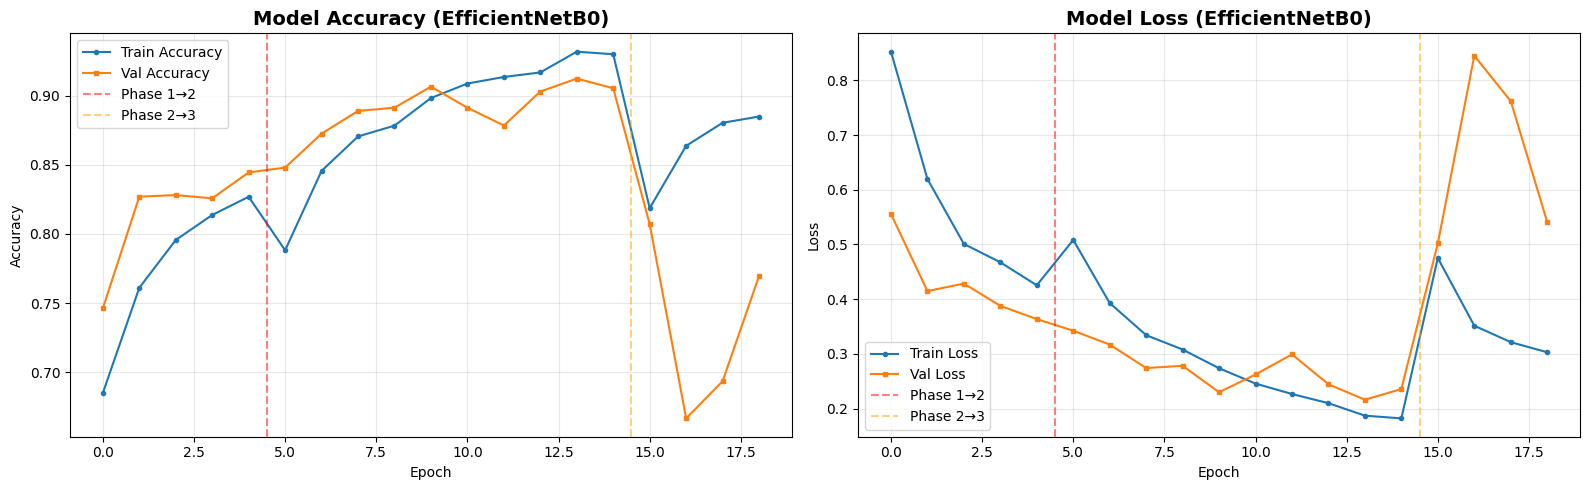

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Mark phase boundaries
phase1_end = len(history_phase1.history['accuracy'])
phase2_end = phase1_end + len(history_phase2.history['accuracy'])

# Plot accuracy
ax1.plot(combined_history['accuracy'], label='Train Accuracy', marker='o', markersize=3)
ax1.plot(combined_history['val_accuracy'], label='Val Accuracy', marker='s', markersize=3)
ax1.axvline(x=phase1_end-0.5, color='red', linestyle='--', alpha=0.5, label='Phase 1→2')
ax1.axvline(x=phase2_end-0.5, color='orange', linestyle='--', alpha=0.5, label='Phase 2→3')
ax1.set_title('Model Accuracy (EfficientNetB0)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot loss
ax2.plot(combined_history['loss'], label='Train Loss', marker='o', markersize=3)
ax2.plot(combined_history['val_loss'], label='Val Loss', marker='s', markersize=3)
ax2.axvline(x=phase1_end-0.5, color='red', linestyle='--', alpha=0.5, label='Phase 1→2')
ax2.axvline(x=phase2_end-0.5, color='orange', linestyle='--', alpha=0.5, label='Phase 2→3')
ax2.set_title('Model Loss (EfficientNetB0)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()

viz_path = os.path.join(VIZ_DIR, f"day4_advanced_efficientnet_history_{timestamp}.png")
plt.savefig(viz_path, dpi=300, bbox_inches='tight')
print(f"Training curves saved to: {viz_path}")

plt.show()

## 11. Evaluate on Test Set

In [11]:
print("🔍 Evaluating on test set...\n")

# Evaluate
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"\n{'='*70}")
print(f"📊 EfficientNetB0 Test Results")
print(f"{'='*70}")
print(f"  Test Loss:     {test_loss:.4f}")
print(f"  Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"{'='*70}")

# Compare with baseline
baseline_accuracy = 0.7683  # From day4_01
improvement = (test_accuracy - baseline_accuracy) * 100

print(f"\n💡 Comparison with Baseline CNN:")
print(f"  Baseline:     76.83%")
print(f"  EfficientNet: {test_accuracy*100:.2f}%")
print(f"  Improvement:  {improvement:+.2f}%")

# Save results
results = {
    'model': 'EfficientNetB0',
    'timestamp': timestamp,
    'test_loss': float(test_loss),
    'test_accuracy': float(test_accuracy),
    'baseline_accuracy': float(baseline_accuracy),
    'improvement': float(improvement),
    'total_epochs': len(combined_history['accuracy']),
    'model_path': model_path_final
}

results_path = os.path.join(HISTORY_DIR, f"efficientnet_results_{timestamp}.json")
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"\nResults saved to: {results_path}")

🔍 Evaluating on test set...

46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.7690 - loss: 0.5726

📊 EfficientNetB0 Test Results
  Test Loss:     0.5726
  Test Accuracy: 0.7690 (76.90%)

💡 Comparison with Baseline CNN:
  Baseline:     76.83%
  EfficientNet: 76.90%
  Improvement:  +0.07%

Results saved to: ../../outputs/training_history/transfer_learning/efficientnet_results_20251024_213202.json
46/46 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.7690 - loss: 0.5726

📊 EfficientNetB0 Test Results
  Test Loss:     0.5726
  Test Accuracy: 0.7690 (76.90%)

💡 Comparison with Baseline CNN:
  Baseline:     76.83%
  EfficientNet: 76.90%
  Improvement:  +0.07%

Results saved to: ../../outputs/training_history/transfer_learning/efficientnet_results_20251024_213202.json


## 12. Summary

In [ ]:
print("\n" + "="*70)
print("🎉 EFFICIENTNET TRAINING COMPLETE!")
print("="*70)

print("\n📊 Final Results:")
print(f"  Model: EfficientNetB0")
print(f"  Test Accuracy: {test_accuracy*100:.2f}%")
print(f"  Baseline: 76.83%")
print(f"  Improvement: {improvement:+.2f}%")

print("\n📁 Files Created:")
print(f"  ✅ Final Model: {model_path_final}")
print(f"  ✅ History CSV: {history_csv}")
print(f"  ✅ Results JSON: {results_path}")
print(f"  ✅ Visualization: {viz_path}")

print("\n🎯 Next Steps:")
print("  1. Train ResNet50 (day4_advanced_resnet50.ipynb)")
print("  2. Train DenseNet121 (day4_advanced_densenet121.ipynb)")
print("  3. Create ensemble (day4_advanced_ensemble.ipynb)")
print("  4. Expected ensemble accuracy: 92-95%")

print("\n💡 Interpretation:")
if test_accuracy >= 0.92:
    print("  🌟 Outstanding! Excellent performance!")
elif test_accuracy >= 0.88:
    print("  ✅ Excellent! Significant improvement over baseline!")
elif test_accuracy >= 0.82:
    print("  ✅ Good! Notable improvement!")
else:
    print("  ⚠️  Moderate improvement - try adjusting hyperparameters")

print("\n" + "="*70)


🎉 EFFICIENTNET TRAINING COMPLETE!

📊 Final Results:
  Model: EfficientNetB0
  Test Accuracy: 76.90%
  Baseline: 76.83%
  Improvement: +0.07%

📁 Files Created:
  ✅ Final Model: ../../outputs/models/transfer_learning/efficientnet_final_20251024_213202.keras
  ✅ History CSV: ../../outputs/training_history/transfer_learning/efficientnet_history_20251024_213202.csv
  ✅ Results JSON: ../../outputs/training_history/transfer_learning/efficientnet_results_20251024_213202.json
  ✅ Visualization: ../../outputs/visualizations/day4_advanced_efficientnet_history_20251024_213202.png

🎯 Next Steps:
  1. Train ResNet50 (day4_advanced_resnet50.ipynb)
  2. Train DenseNet121 (day4_advanced_densenet121.ipynb)
  3. Create ensemble (day4_advanced_ensemble.ipynb)
  4. Expected ensemble accuracy: 92-95%

💡 Interpretation:
  ⚠️  Moderate improvement - try adjusting hyperparameters



: 